In [3]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


In [9]:
import matplotlib.pyplot as plt

In [4]:
from train import ConsumptionModelTrainer
from data_processor import LSTMDataPreparator, DataPreprocessor

In [1]:
1+1

2

In [5]:
data_dir = Path("..") / "data"
file_elec_consum = data_dir / 'Electricity consumption.csv'
file_weather = data_dir / 'Weather data.csv'

In [6]:
df_valid = DataPreprocessor(file_elec_consum, file_weather).feature_engineering_consumption()

Loading and preparing data...
Filling values below 205 kW with historical means...
Handling weekend outliers...
Handling weekday outliers...
Threshold applied for day 0: 770.00 kW
Threshold applied for day 1: 760.00 kW
Threshold applied for day 2: 720.00 kW
Threshold applied for day 3: 700.00 kW
Threshold applied for day 4: 670.00 kW
Calculating daily energy consumption...
Processing complete!
Loading and preparing data...
Filling values below 4 with historical ...
Processing complete!


In [7]:
if __name__ == "__main__":
    
    lstm_preparator = LSTMDataPreparator(
        window=14,          
        horizon=7,       
        train_ratio=0.7,
        val_ratio=0.15,
        feature_scaler_type='minmax',
        target_scaler_type='minmax',
        verbose=True
    )
    
    lstm_preparator.prepare(df_valid)
    
    X_train, y_train = lstm_preparator.get_training_data()
    X_val, y_val = lstm_preparator.get_validation_data()
    X_test, y_test = lstm_preparator.get_test_data()
    
    all_data = lstm_preparator.get_all_data()
    
    
    print("\nData ready for LSTM model!")

1. Selecting features...
2. Creating LSTM sequences...
3. Splitting data...
4. Scaling features...
5. Scaling targets...

Data ready for LSTM model!


In [ ]:
lstm_preparator.save_preparator_artifacts()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 14, 128)        │        57,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,079 (387.03 KB)

 Trainable params: 99,079 (387.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - loss: 0.3101 - mae: 0.3101 - mse: 0.1461 - val_loss: 0.1719 - val_mae: 0.1719 - val_mse: 0.0529
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2232 - mae: 0.2232 - mse: 0.0746 - val_loss: 0.1485 - val_mae: 0.1485 - val_mse: 0.0332
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.2045 - mae: 0.2045 - mse: 0.0643 - val_loss: 0.1348 - val_mae: 0.1348 - val_mse: 0.0279
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1832 - mae: 0.1832 - mse: 0.0522 - val_loss: 0.1189 - val_mae: 0.1189 - val_mse: 0.0223
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1748 - mae: 0.1748 - mse: 0.0480 - val_loss: 0.1163 - val_mae: 0.1163 - val_mse: 0.0208
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1628 - mae: 0.1628 - mse: 0.0422 - val_loss: 0.1066 - val_mae: 0.1066 - val_mse: 0.0182
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1533 - mae: 0.1533 - mse: 0.0385 - val_loss: 0.1023

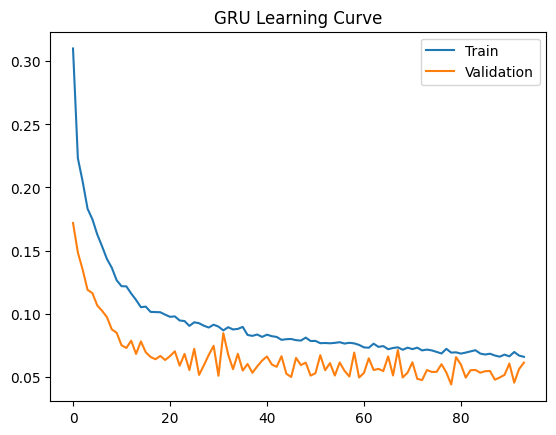

In [8]:
if __name__ == "__main__":
    
    trainer = ConsumptionModelTrainer(
    )
    
    trainer.build_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        horizon=y_train.shape[1]
    ).compile_model().show_summary()
    
    history = trainer.train(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val
    )
    
    trainer.visualize_training()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step


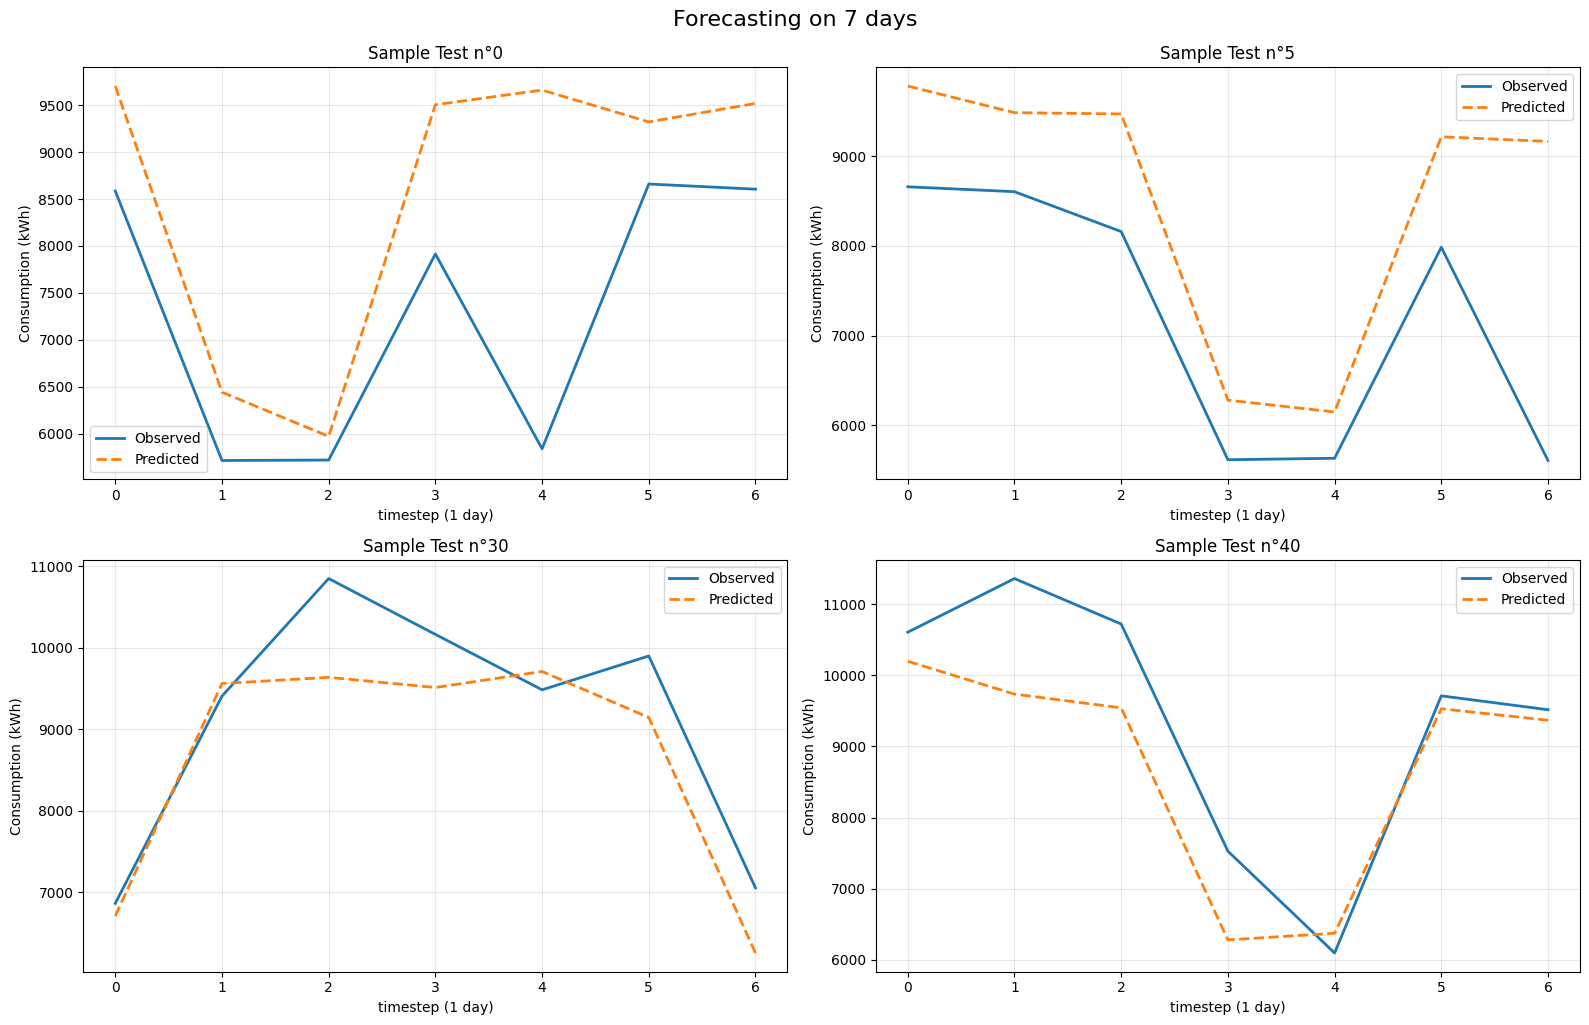

In [10]:
model_gru = trainer.get_model()
y_pred_scaled = model_gru.predict(X_test)

y_pred_kw = lstm_preparator.inverse_transform_targets(y_pred_scaled)
y_test_kw = lstm_preparator.inverse_transform_targets(y_test)

indices_to_plot = [0, 5, 30, 40]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, idx in enumerate(indices_to_plot):
    axes[i].plot(y_test_kw[idx], label="Observed", color='#1f77b4', linewidth=2)
    axes[i].plot(y_pred_kw[idx], label="Predicted", color='#ff7f0e', linestyle='--', linewidth=2)

    axes[i].set_title(f"Sample Test n°{idx}")
    axes[i].set_ylabel("Consumption (kWh)")
    axes[i].set_xlabel("timestep (1 day)")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Forecasting on 7 days", fontsize=16, y=1.02)
plt.show()

In [11]:
if __name__ == "__main__":
    
    
    X_lstm = lstm_preparator.X_sequences

    y_lstm = lstm_preparator.y_sequences


## **Cross Validation**

In [13]:
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, GRU, Dropout, Input

horizon = 7

def build_model():
    model = Sequential([
        Input(shape=(14, X_lstm.shape[2])),
        GRU(128, return_sequences=True),
        Dropout(0.3),
        GRU(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(horizon)
    ])
    return model

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

tscv = TimeSeriesSplit(n_splits=6)
horizon = 7
fold = 1
for train_index, test_index in tscv.split(X_lstm):
    X_train_fold, X_test_fold = X_lstm[train_index], X_lstm[test_index]
    y_train_fold, y_test_fold = y_lstm[train_index], y_lstm[test_index]

    s_x = MinMaxScaler()
    n_t, w, f = X_train_fold.shape
    X_train_fold = s_x.fit_transform(X_train_fold.reshape(-1, f)).reshape(n_t, w, f)
    X_test_fold = s_x.transform(X_test_fold.reshape(-1, f)).reshape(-1, w, f)

    s_y = MinMaxScaler()
    y_train_fold = s_y.fit_transform(y_train_fold)
    y_test_fold = s_y.transform(y_test_fold)

    print(f"--- Training Fold {fold} ---")
    print(f"size Train: {len(X_train_fold)}, size Test: {len(X_test_fold)}")

    model = build_model()

    model.compile(optimizer='adam', loss='mae')

    model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, verbose=0)

    score = model.evaluate(X_test_fold, y_test_fold, verbose=0)
    print(f"MAE on fold {fold}: {score}")
    fold += 1

--- Training Fold 1 ---
size Train: 56, size Test: 56
MAE on fold 1: 0.1559602916240692
--- Training Fold 2 ---
size Train: 112, size Test: 56
MAE on fold 2: 0.17148540914058685
--- Training Fold 3 ---
size Train: 168, size Test: 56
MAE on fold 3: 0.09415755420923233
--- Training Fold 4 ---
size Train: 224, size Test: 56
MAE on fold 4: 0.12857943773269653
--- Training Fold 5 ---
size Train: 280, size Test: 56
MAE on fold 5: 0.04957345873117447
--- Training Fold 6 ---
size Train: 336, size Test: 56
MAE on fold 6: 0.0920603945851326


In [15]:
import numpy as np
#model_gru = trainer.get_model()

def predict_with_uncertainty(model, X_input, n_iter=100):
    predictions = []
    for _ in range(n_iter):
        predictions.append(model(X_input, training=True))

    predictions = np.array(predictions)

    prediction_mean = np.mean(predictions, axis=0)
    prediction_std = np.std(predictions, axis=0)

    return prediction_mean, prediction_std
features_lstm = lstm_preparator.feature_selector.default_features
last_window_raw = df_valid[features_lstm].values[-14:]

last_window_scaled = lstm_preparator.feature_scaler.transform(last_window_raw.reshape(1, *last_window_raw.shape))
mean_scaled, std_scaled = predict_with_uncertainty(model_gru, last_window_scaled)

mean_final = lstm_preparator.inverse_transform_targets(mean_scaled).flatten()
upper_bound = lstm_preparator.inverse_transform_targets((mean_scaled + 1.96 * std_scaled)).flatten()
lower_bound = lstm_preparator.inverse_transform_targets((mean_scaled - 1.96 * std_scaled)).flatten()

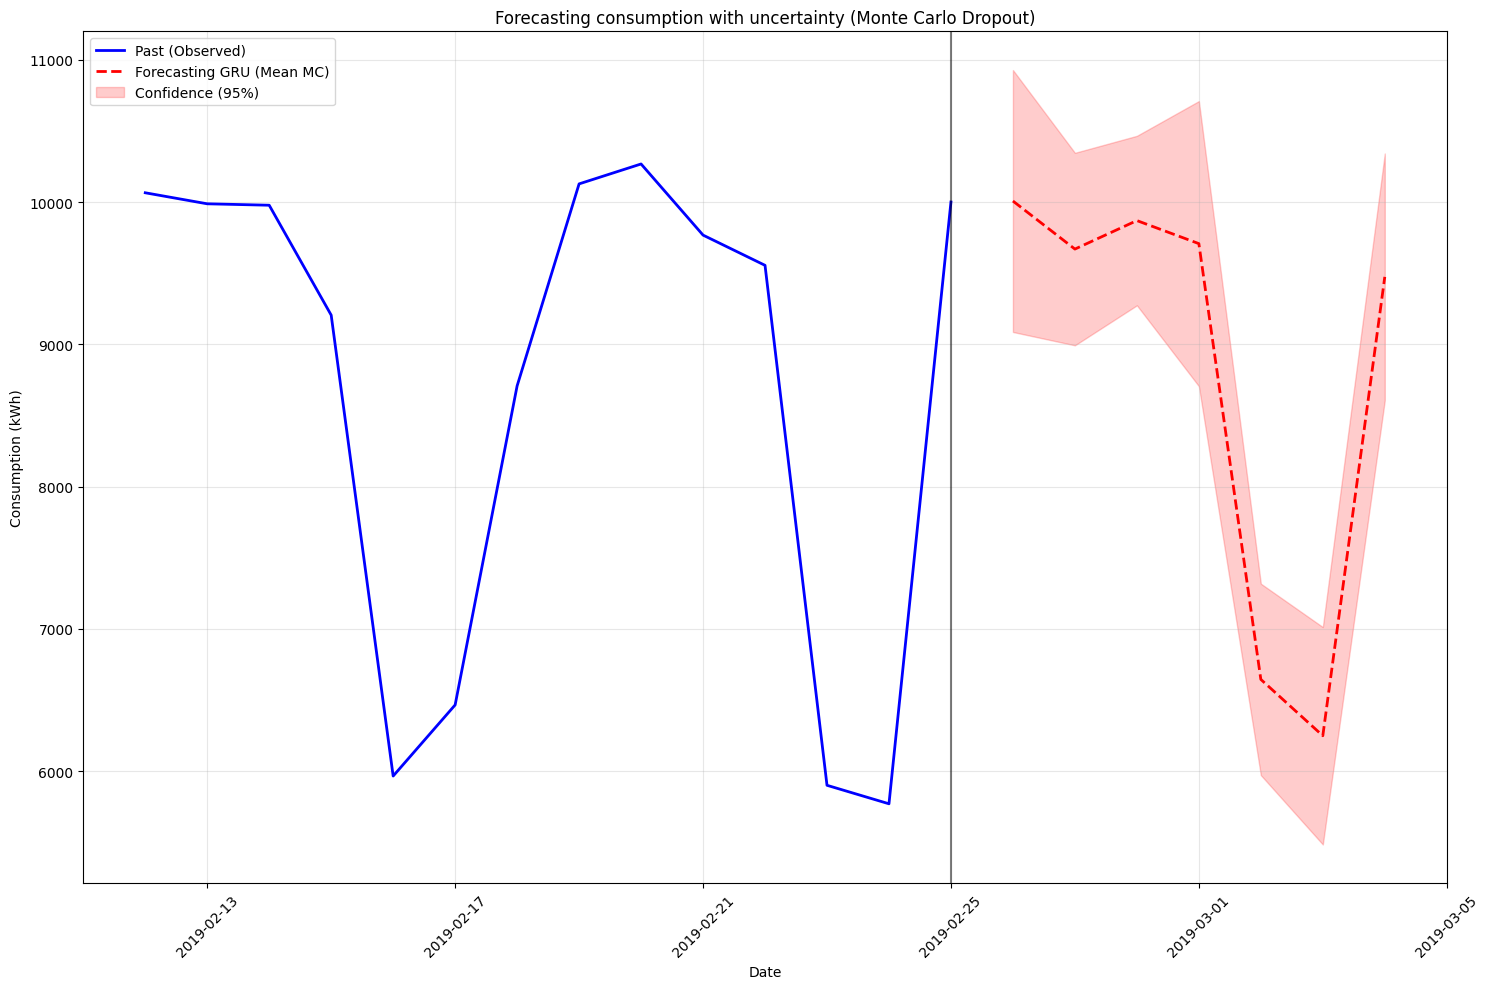

In [16]:
import matplotlib.pyplot as plt

last_date = df_valid.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='1D')


plt.figure(figsize=(15, 10))

past_visible = df_valid.tail(14)
plt.plot(past_visible.index, past_visible['energy_interval_kWh'],
         label='Past (Observed)', color='blue', lw=2)

plt.plot(forecast_dates, mean_final,
         label='Forecasting GRU (Mean MC)', color='red', linestyle='--', lw=2)

plt.fill_between(forecast_dates, lower_bound, upper_bound,
                 color='red', alpha=0.2, label='Confidence (95%)')

plt.axvline(x=last_date, color='black', linestyle='-', alpha=0.5)
plt.title(f"Forecasting consumption with uncertainty (Monte Carlo Dropout)")
plt.xlabel("Date")
plt.ylabel("Consumption (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
y_pred_scaled = model_gru.predict(X_test)
y_pred_train_scaled = model_gru.predict(X_train)

y_pred_kw = lstm_preparator.inverse_transform_targets(y_pred_scaled)
y_pred_kw_train = lstm_preparator.inverse_transform_targets(y_pred_train_scaled)
y_train_kw = lstm_preparator.inverse_transform_targets(y_train)
y_test_kw = lstm_preparator.inverse_transform_targets(y_test)

Modèle: GRU

Performance sur Train:
MSE: 697984.827580
RMSE: 835.454863
MAE: 607.701779
R²: 0.862512

Performance sur Test:
MSE: 959201.626483
RMSE: 979.388394
MAE: 705.820234
R²: 0.676041


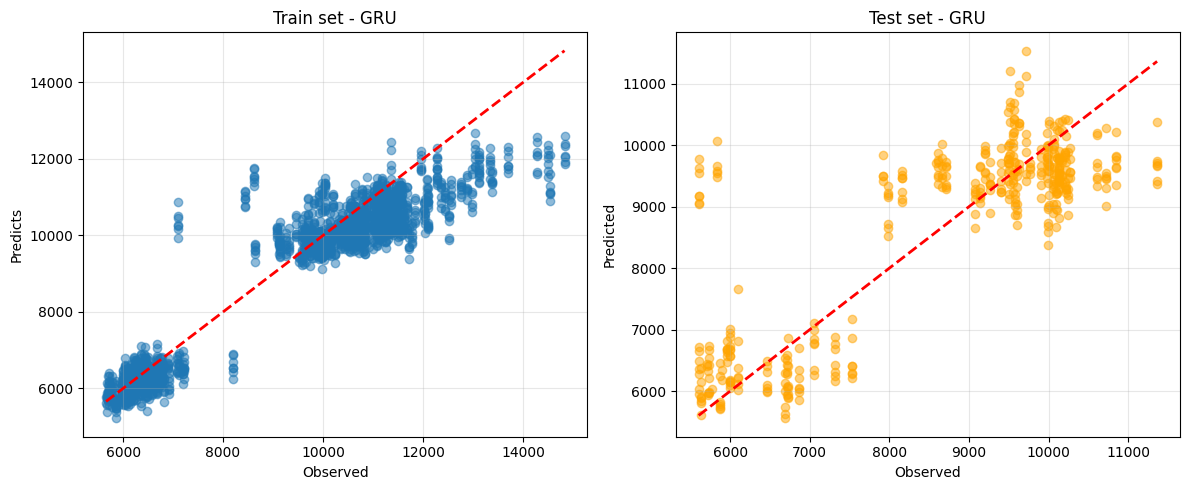

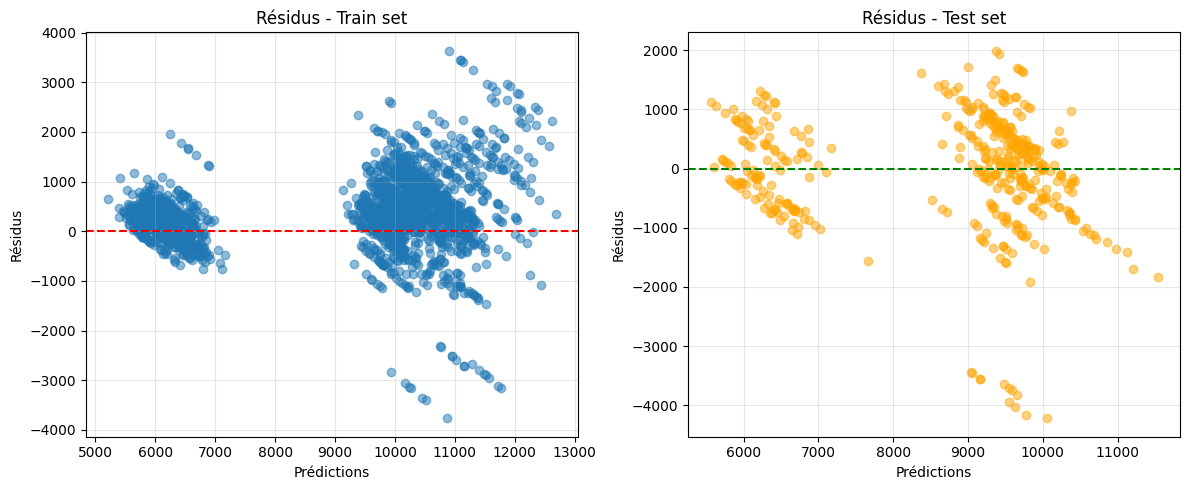

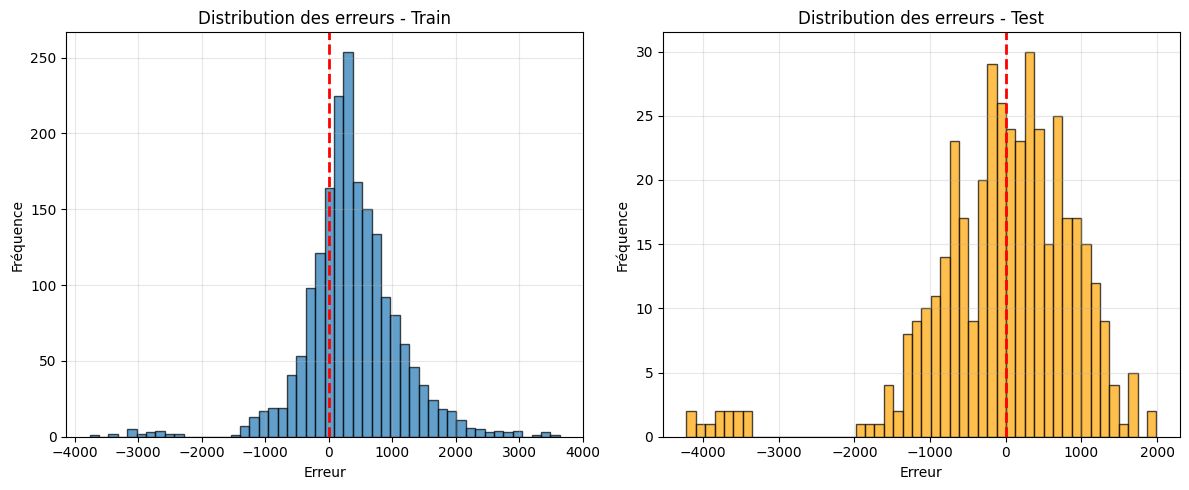

In [18]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"Performance sur {dataset_name}:")
    print(f"{'='*50}")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R²: {r2:.6f}")

    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
print(f"Modèle: GRU")
# Assurez-vous d'utiliser les versions dé-normalisées pour les métriques
train_metrics = evaluate_model(y_train_kw, y_pred_kw_train, "Train")
test_metrics = evaluate_model(y_test_kw, y_pred_kw, "Test")

# 6. Visualisation des prédictions vs vraies valeurs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
axes[0].scatter(y_train_kw, y_pred_kw_train, alpha=0.5)
axes[0].plot([y_train_kw.min(), y_train_kw.max()], [y_train_kw.min(), y_train_kw.max()], 'r--', lw=2)
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicts')
axes[0].set_title('Train set - GRU')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test_kw, y_pred_kw, alpha=0.5, color='orange')
axes[1].plot([y_test_kw.min(), y_test_kw.max()], [y_test_kw.min(), y_test_kw.max()], 'r--', lw=2)
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test set - GRU')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

residuals_train = y_train_kw - y_pred_kw_train
residuals_test = y_test_kw - y_pred_kw

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_kw_train, residuals_train, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Prédictions')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus - Train set')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_kw, residuals_test, alpha=0.5, color='orange')
axes[1].axhline(y=0, color='g', linestyle='--')
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Résidus - Test set')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals_train.flatten(), bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Erreur')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des erreurs - Train')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_test.flatten(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Erreur')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des erreurs - Test')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [19]:
df_valid = DataPreprocessor(file_elec_consum, file_weather).feature_engineering_consumption()
if __name__ == "__main__":
    
    lstm_preparator = LSTMDataPreparator(
        window=14,           # 2 weeks lookback
        horizon=7,           # 1 week prediction
        train_ratio=1.0,
        val_ratio=0.0,
        feature_scaler_type='minmax',
        target_scaler_type='minmax',
        verbose=True
    )
    
    # Prepare the data
    lstm_preparator.prepare(df_valid)
    
    X_train, y_train = lstm_preparator.get_training_data()
    
    # Get all data at once
    all_data = lstm_preparator.get_all_data()
    
    print("\nData ready for LSTM model!")

Loading and preparing data...
Filling values below 205 kW with historical means...
Handling weekend outliers...
Handling weekday outliers...
Threshold applied for day 0: 770.00 kW
Threshold applied for day 1: 760.00 kW
Threshold applied for day 2: 720.00 kW
Threshold applied for day 3: 700.00 kW
Threshold applied for day 4: 670.00 kW
Calculating daily energy consumption...
Processing complete!
Loading and preparing data...
Filling values below 4 with historical ...
Processing complete!
1. Selecting features...
2. Creating LSTM sequences...
3. Splitting data...
4. Scaling features...
5. Scaling targets...

Data ready for LSTM model!


In [20]:
if __name__ == "__main__":
    
    trainer = ConsumptionModelTrainer(
    )
    
    trainer.build_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        horizon=y_train.shape[1]
    ).compile_model().show_summary()
    
    history = trainer.train(
        X_train=X_train,
        y_train=y_train
    )

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_14 (GRU)                    │ (None, 14, 128)        │        57,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,079 (387.03 KB)

 Trainable params: 99,079 (387.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2575 - mae: 0.2575 - mse: 0.1032
Epoch 2/100
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2064 - mae: 0.2064 - mse: 0.0633

c:\Users\etulyon1\forecasting_electricity\.venv\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae,mse
  current = self.get_monitor_value(logs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1990 - mae: 0.1990 - mse: 0.0600
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1801 - mae: 0.1801 - mse: 0.0508
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1609 - mae: 0.1609 - mse: 0.0401
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1417 - mae: 0.1417 - mse: 0.0323
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1325 - mae: 0.1325 - mse: 0.0299
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1243 - mae: 0.1243 - mse: 0.0262
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1172 - mae: 0.1172 - mse: 0.0238
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1126 - mae: 0.1126 - mse: 0.0217
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1073 - mae: 0.1073 - mse: 0.0202
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1011 - mae: 0.1011 - mse: 0.0180
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss:

In [21]:
from utils.inference_evaluation.predict_ci import predict_with_uncertainty
model_gru = trainer.get_model()


features_lstm = lstm_preparator.feature_selector.default_features
last_window_raw = df_valid[features_lstm].values[-14:]

last_window_scaled = lstm_preparator.feature_scaler.transform(last_window_raw.reshape(1, *last_window_raw.shape))
mean_scaled, std_scaled = predict_with_uncertainty(model_gru, last_window_scaled)

mean_final = lstm_preparator.inverse_transform_targets(mean_scaled).flatten()
upper_bound = lstm_preparator.inverse_transform_targets((mean_scaled + 1.96 * std_scaled)).flatten()
lower_bound = lstm_preparator.inverse_transform_targets((mean_scaled - 1.96 * std_scaled)).flatten()

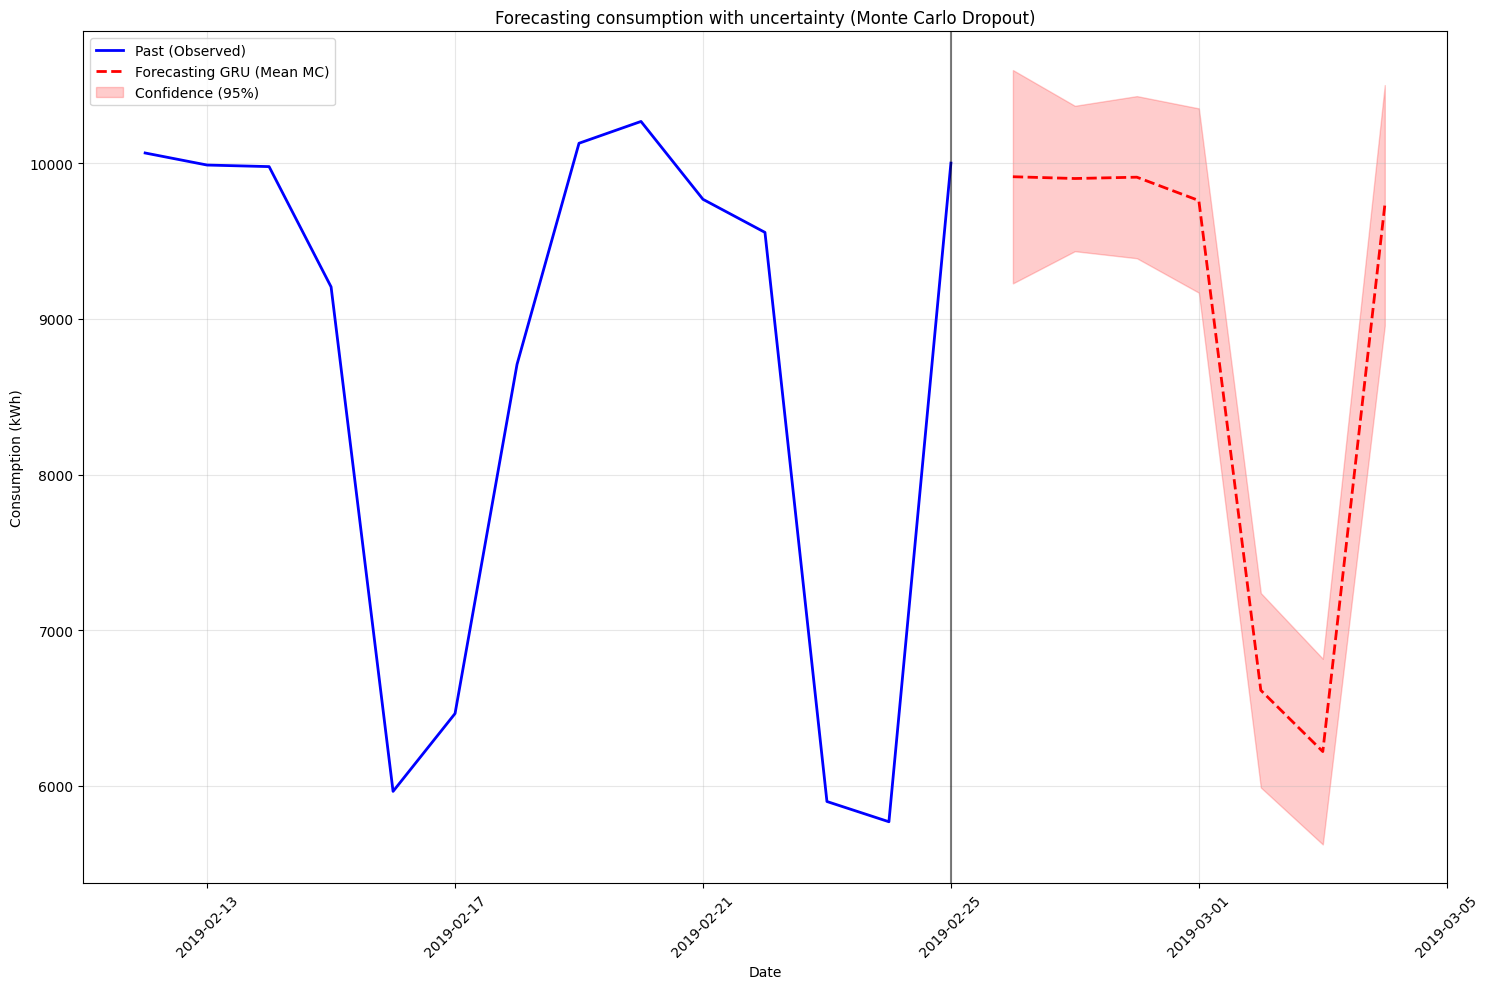

In [22]:
import matplotlib.pyplot as plt

last_date = df_valid.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='1D')


plt.figure(figsize=(15, 10))

past_visible = df_valid.tail(14)
plt.plot(past_visible.index, past_visible['energy_interval_kWh'],
         label='Past (Observed)', color='blue', lw=2)

plt.plot(forecast_dates, mean_final,
         label='Forecasting GRU (Mean MC)', color='red', linestyle='--', lw=2)

plt.fill_between(forecast_dates, lower_bound, upper_bound,
                 color='red', alpha=0.2, label='Confidence (95%)')

# Mise en forme
plt.axvline(x=last_date, color='black', linestyle='-', alpha=0.5)
plt.title(f"Forecasting consumption with uncertainty (Monte Carlo Dropout)")
plt.xlabel("Date")
plt.ylabel("Consumption (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
trainer.save_model()
lstm_preparator.save_preparator_artifacts()

Successfully saved : models/energy_model.keras
Artefacts saved at : models
